In [1]:
!pip install wbgapi

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
indicators = {
    # === MEVCUT GÖSTERGELER ===
    'SP.DYN.LE00.IN': 'Yasam_Beklentisi',
    'SE.SEC.ENRR': 'Lise_Okullasma_Orani',
    'SH.XPD.CHEX.PC.CD': 'Kisi_Basi_Saglik_Harcamasi',
    'EN.ATM.PM25.MC.M3': 'Hava_Kirliligi_PM25',
    'EN.ATM.CO2E.KT': 'CO2_Emisyonu_KiloTon',
    'SP.POP.TOTL': 'Nufus',
    'SP.DYN.IMRT.IN': 'Bebek_Olum_Orani',
    'SH.DYN.MORT': 'Bes_Yas_Alti_Olum',
    'SH.IMM.HEPB': 'Asi_Hepatit_B',
    'SH.IMM.MEAS': 'Asi_Kizamik',
    'SH.IMM.POL3': 'Asi_Cocuk_Felci',
    'SH.IMM.IDPT': 'Asi_Difteri',
    'SH.DYN.AIDS.ZS': 'HIV_Prevalansi',
    'SH.ALC.PCAP.LI': 'Alkol_Tuketimi',

    # === YENİ: KARBON EMİSYONLARI ===
    'EN.ATM.CO2E.PC':   'CO2_Emisyonu_KisiBasI',      # ton/kişi
    'EN.ATM.METH.KT.CE':'Metan_Emisyonu_KT',           # CO2 eşdeğeri kt
    'EN.ATM.NOXE.KT.CE':'N2O_Emisyonu_KT',             # CO2 eşdeğeri kt
    'EN.ATM.GHGT.KT.CE':'Toplam_Sera_Gazi_KT',         # tüm GHG toplamı

    # === YENİ: ENERJİ & YAKIT ===
    'EG.FEC.RNEW.ZS':   'Yenilenebilir_Enerji_Payi',  # % toplam enerji
    'EG.USE.COMM.FO.ZS':'Fosil_Yakit_Tuketimi',        # % toplam enerji
    'EG.USE.PCAP.KG.OE':'Kisi_Basi_Enerji_Tuketimi',  # kg petrol eşdeğeri
    'EG.ELC.COAL.ZS':   'Komur_Elektrik_Payi',         # % elektrik üretimi
    'EG.ELC.RNWX.ZS':   'Yenilenebilir_Elektrik_Payi',# % elektrik üretimi

    # === YENİ: ORMAN KAYBI / ARAZİ KULLANIMI ===
    'AG.LND.FRST.ZS':   'Orman_Alani_Yuzdesi',         # % kara alanı
    'AG.LND.FRST.K2':   'Orman_Alani_KM2',             # km²
    'AG.LND.AGRI.ZS':   'Tarim_Arazisi_Yuzdesi',       # % kara alanı

    # === YENİ: SU KİRLİLİĞİ ===
    'EE.BOD.TOTL.KG':   'Su_BOD_Emisyonu_KG',          # kg/gün organik kirlilik
    'ER.H2O.FWTL.ZS':   'Tatli_Su_Cekim_Orani',        # % iç kaynaklar
    'SH.H2O.SMDW.ZS':   'Guvenli_Icme_Suyu_Erisimi',   # % nüfus
    'SH.STA.SMSS.ZS':   'Guvenli_Sanitasyon_Erisimi',  # % nüfus
}

print("Genişletilmiş veri seti Dünya Bankası'ndan çekiliyor, lütfen bekleyin...")

# 2. Adım: Veriyi Çekme (2000-2020)
raw_data = wb.data.DataFrame(indicators.keys(), time=range(2000, 2021), numericTimeKeys=True)

# 3. Adım: Veriyi Düzenleme (Geniş formattan Uzun formata)
df_reset = raw_data.reset_index()
df_melted = df_reset.melt(id_vars=['economy', 'series'], var_name='Yil', value_name='Deger')
df_final = df_melted.pivot_table(index=['economy', 'Yil'], columns='series', values='Deger').reset_index()

# Sütun isimlerini Türkçeleştirme
df_final.rename(columns=indicators, inplace=True)
df_final.rename(columns={'economy': 'Ulke_Kodu'}, inplace=True)

# 4. Adım: Ülke Meta Verilerini Çekme (Kıta ve Gelir Durumu)
countries = wb.economy.DataFrame()
meta_data = countries[['name', 'region', 'incomeLevel']].copy()
meta_data.rename(columns={
    'name': 'Ulke_Adi',
    'region': 'Bolge_Kodu',
    'incomeLevel': 'Gelismişlik_Durumu'
}, inplace=True)

# Verileri birleştirme
df_final = df_final.merge(meta_data, left_on='Ulke_Kodu', right_index=True, how='inner')

# 5. Adım: Sadece Avrupa ve Asya'yı Filtreleme
hedef_bolgeler = ['ECS', 'EAS', 'SAS']
df_filtered = df_final[df_final['Bolge_Kodu'].isin(hedef_bolgeler)].copy()

# İsimleri Türkçeleştirme
df_filtered['Kita'] = df_filtered['Bolge_Kodu'].map({
    'ECS': 'Avrupa ve Orta Asya', 'EAS': 'Doğu Asya ve Pasifik', 'SAS': 'Güney Asya'
})

df_filtered['Gelismişlik_Durumu'] = df_filtered['Gelismişlik_Durumu'].map({
    'HIC': 'Yüksek Gelirli (Gelişmiş)', 'UMC': 'Üst-Orta Gelirli',
    'LMC': 'Alt-Orta Gelirli', 'LIC': 'Düşük Gelirli (Gelişmemiş)', 'INX': 'Sınıflandırılmamış'
})

# 6. Adım: Dinamik Sütun Seçimi (Hata Önleyici Sistem)
temel_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil']
veri_sutunlari = list(indicators.values())
istenen_sutunlar = temel_sutunlar + veri_sutunlari
mevcut_sutunlar = [col for col in istenen_sutunlar if col in df_filtered.columns]

# Nihai tabloyu oluştur ve sırala
df_analiz = df_filtered[mevcut_sutunlar].sort_values(by=['Ulke_Adi', 'Yil']).reset_index(drop=True)

print("\nVeri hazırlığı başarıyla tamamlandı!")
print(f"Toplam Satır Sayısı: {len(df_analiz)}")
print(f"Toplam Sütun (Değişken) Sayısı: {df_analiz.shape[1]}")
display(df_analiz.head())

Genişletilmiş veri seti Dünya Bankası'ndan çekiliyor, lütfen bekleyin...

Veri hazırlığı başarıyla tamamlandı!
Toplam Satır Sayısı: 2121
Toplam Sütun (Değişken) Sayısı: 28


,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
0,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,74.826,70.318649,65.476746,22.265189,3089027.0,...,58.626225,581.374749,0.0,0.000000,28.076642,7693.00,41.751825,6.831970,49.138320,22.879987
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,60.857697,598.228317,0.0,0.003753,28.123248,7705.77,41.569343,6.507286,49.081199,23.475974
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,63.130793,661.117952,0.0,0.007223,28.169854,7718.54,41.605839,6.182602,48.984766,24.036737
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,64.410168,649.357881,0.0,0.005409,28.216460,7731.31,40.912409,5.857918,48.885443,24.576771
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,65.467668,716.623146,0.0,0.004816,28.263066,7744.08,40.948905,5.533234,50.717678,25.095910


In [4]:
import wbgapi as wb
import pandas as pd

# Belirlediğimiz yeni göstergelerin kodları
new_indicators = {
    'IT.NET.USER.ZS': 'Internet_Usage',
    'SI.POV.GINI': 'Gini_Index',
    'IS.AIR.PSGR': 'Air_Passengers',
    'SH.STA.SUIC.P5': 'Suicide_Rate'
}

# Verileri çekme (Mevcut projenin tarih aralığına uygun: 2000-2020)
df_new = wb.data.DataFrame(new_indicators.keys(),
                           time=range(2000, 2021),
                           labels=True).rename(columns=new_indicators)

In [5]:
raw_new_data_for_merge = wb.data.DataFrame(new_indicators.keys(), time=range(2000, 2021), numericTimeKeys=True)

df_new_reset = raw_new_data_for_merge.reset_index()

df_new_melted = df_new_reset.melt(id_vars=['economy', 'series'], var_name='Yil', value_name='Deger')

df_new_final = df_new_melted.pivot_table(index=['economy', 'Yil'], columns='series', values='Deger').reset_index()

df_new_final.rename(columns={'economy': 'Ulke_Kodu'}, inplace=True)
df_new_final.rename(columns=new_indicators, inplace=True)

df_combined = pd.merge(df_analiz, df_new_final, on=['Ulke_Kodu', 'Yil'], how='left')

display(df_combined.head())

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi,Air_Passengers,Internet_Usage,Suicide_Rate,Gini_Index
0,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,74.826,70.318649,65.476746,22.265189,3089027.0,...,28.076642,7693.00,41.751825,6.831970,49.138320,22.879987,136622.0,0.114097,4.78,NaN
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,28.123248,7705.77,41.569343,6.507286,49.081199,23.475974,146273.0,0.325798,4.19,NaN
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,28.169854,7718.54,41.605839,6.182602,48.984766,24.036737,137569.0,0.390081,4.28,31.7
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,28.216460,7731.31,40.912409,5.857918,48.885443,24.576771,158888.0,0.971900,4.47,NaN
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,28.263066,7744.08,40.948905,5.533234,50.717678,25.095910,179543.0,2.420388,4.44,NaN


In [6]:
df_combined['Air_Passengers_Per_Capita'] = df_combined['Air_Passengers'] / df_combined['Nufus']

df_combined['Forest_Area_Per_Capita'] = df_combined['Orman_Alani_KM2'] / df_combined['Nufus']

In [7]:
df_combined['Is_Pandemic'] = (df_combined['Yil'] == 2020).astype(int)

In [8]:
display(df_combined.head())

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi,Air_Passengers,Internet_Usage,Suicide_Rate,Gini_Index,Air_Passengers_Per_Capita,Forest_Area_Per_Capita,Is_Pandemic
0,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,74.826,70.318649,65.476746,22.265189,3089027.0,...,6.831970,49.138320,22.879987,136622.0,0.114097,4.78,NaN,0.044228,0.002490,0
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,6.507286,49.081199,23.475974,146273.0,0.325798,4.19,NaN,0.047799,0.002518,0
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,6.182602,48.984766,24.036737,137569.0,0.390081,4.28,31.7,0.045090,0.002530,0
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,5.857918,48.885443,24.576771,158888.0,0.971900,4.47,NaN,0.052272,0.002544,0
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,5.533234,50.717678,25.095910,179543.0,2.420388,4.44,NaN,0.059315,0.002558,0


In [9]:
# Colab'den dosya indirmek için gerekli kütüphane
from google.colab import files

# Veri setini Excel dosyası olarak kaydetme
# index=False komutu, satır numaralarının Excel'e gereksiz bir sütun olarak eklenmesini önler
dosya_adi = 'Life_Expectancy.xlsx'
df_combined.to_excel(dosya_adi, index=False)

print(f"{dosya_adi} oluşturuldu. Bilgisayarınıza indiriliyor...")

# Dosyayı otomatik olarak bilgisayarınıza indirme komutu
files.download(dosya_adi)

Life_Expectancy.xlsx oluşturuldu. Bilgisayarınıza indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
print(df_combined.columns.tolist())

['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil', 'Yasam_Beklentisi', 'Lise_Okullasma_Orani', 'Kisi_Basi_Saglik_Harcamasi', 'Hava_Kirliligi_PM25', 'Nufus', 'Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum', 'Asi_Hepatit_B', 'Asi_Kizamik', 'Asi_Difteri', 'HIV_Prevalansi', 'Alkol_Tuketimi', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Kisi_Basi_Enerji_Tuketimi', 'Komur_Elektrik_Payi', 'Yenilenebilir_Elektrik_Payi', 'Orman_Alani_Yuzdesi', 'Orman_Alani_KM2', 'Tarim_Arazisi_Yuzdesi', 'Tatli_Su_Cekim_Orani', 'Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi', 'Air_Passengers', 'Internet_Usage', 'Suicide_Rate', 'Gini_Index', 'Air_Passengers_Per_Capita', 'Forest_Area_Per_Capita', 'Is_Pandemic']


In [11]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Ulke_Kodu                    2121 non-null   object 
 1   Ulke_Adi                     2121 non-null   object 
 2   Kita                         2121 non-null   object 
 3   Gelismişlik_Durumu           2121 non-null   object 
 4   Yil                          2121 non-null   int64  
 5   Yasam_Beklentisi             2121 non-null   float64
 6   Lise_Okullasma_Orani         1459 non-null   float64
 7   Kisi_Basi_Saglik_Harcamasi   1800 non-null   float64
 8   Hava_Kirliligi_PM25          1911 non-null   float64
 9   Nufus                        2121 non-null   float64
 10  Bebek_Olum_Orani             1848 non-null   float64
 11  Bes_Yas_Alti_Olum            1848 non-null   float64
 12  Asi_Hepatit_B                1535 non-null   float64
 13  Asi_Kizamik       

In [12]:
eksik_veriler = df_combined.isnull().sum()
print("Eksik Veri Sayıları:")
print(eksik_veriler[eksik_veriler > 0])

eksik_yuzde = (df_combined.isnull().sum() / len(df_combined)) * 100
print("\nEksik Veri Yüzdesi (%):")
print(eksik_yuzde[eksik_yuzde > 0])

Eksik Veri Sayıları:
Lise_Okullasma_Orani            662
Kisi_Basi_Saglik_Harcamasi      321
Hava_Kirliligi_PM25             210
Bebek_Olum_Orani                273
Bes_Yas_Alti_Olum               273
Asi_Hepatit_B                   586
Asi_Kizamik                     302
Asi_Difteri                     302
HIV_Prevalansi                  929
Alkol_Tuketimi                  414
Yenilenebilir_Enerji_Payi        93
Fosil_Yakit_Tuketimi            636
Kisi_Basi_Enerji_Tuketimi       580
Komur_Elektrik_Payi             159
Yenilenebilir_Elektrik_Payi     159
Orman_Alani_Yuzdesi              75
Orman_Alani_KM2                  75
Tarim_Arazisi_Yuzdesi            96
Tatli_Su_Cekim_Orani            642
Guvenli_Icme_Suyu_Erisimi       337
Guvenli_Sanitasyon_Erisimi      531
Air_Passengers                  502
Internet_Usage                  227
Suicide_Rate                    441
Gini_Index                     1097
Air_Passengers_Per_Capita       502
Forest_Area_Per_Capita           75
dtype: 

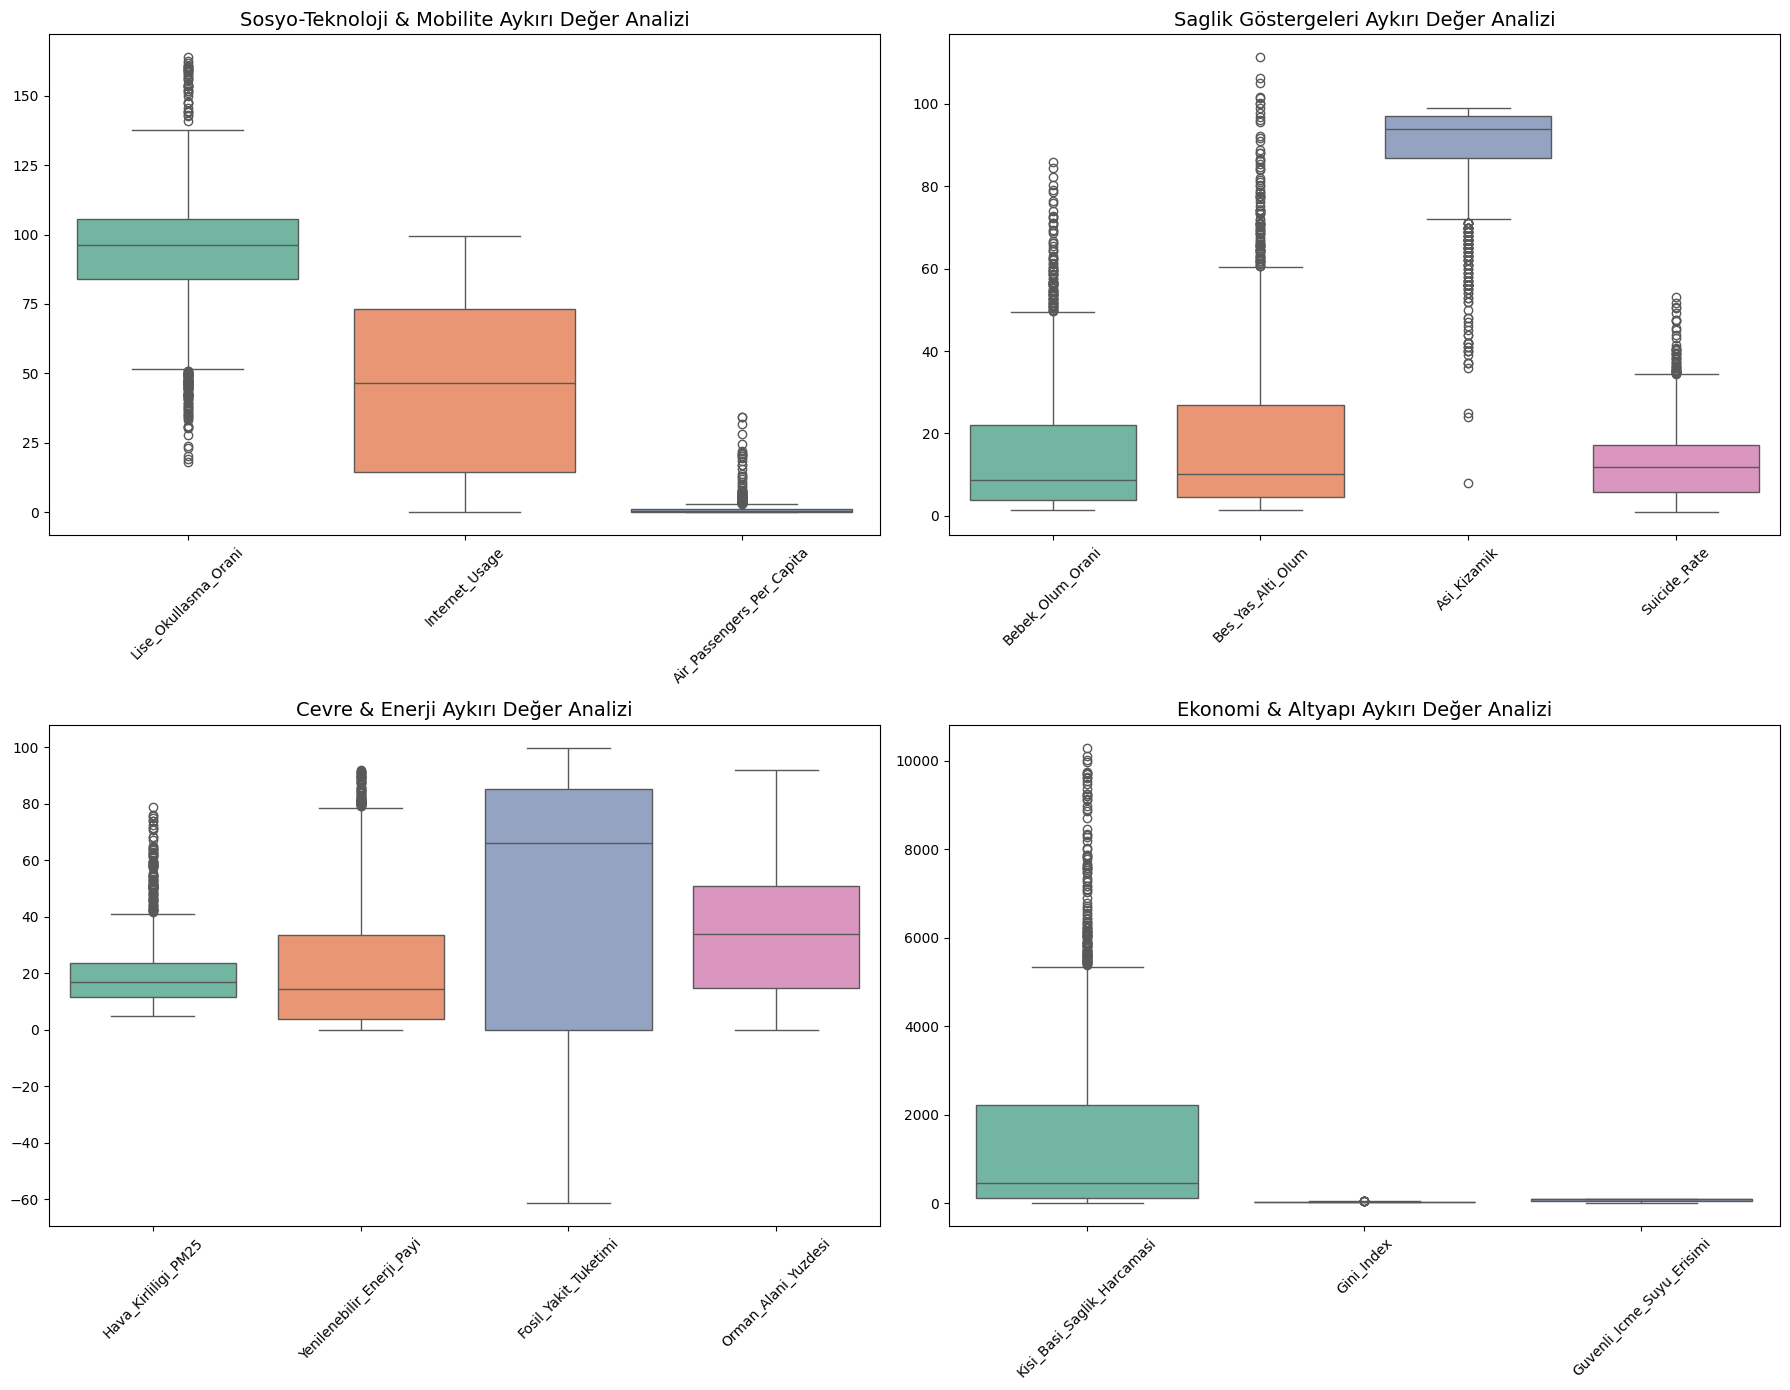

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grupları tanımlayalım (Analiz kolaylığı için)
gruplar = {
    "Sosyo-Teknoloji & Mobilite": ['Lise_Okullasma_Orani', 'Internet_Usage', 'Air_Passengers_Per_Capita'],
    "Saglik Göstergeleri": ['Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum', 'Asi_Kizamik', 'Suicide_Rate'],
    "Cevre & Enerji": ['Hava_Kirliligi_PM25', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Orman_Alani_Yuzdesi'],
    "Ekonomi & Altyapı": ['Kisi_Basi_Saglik_Harcamasi', 'Gini_Index', 'Guvenli_Icme_Suyu_Erisimi']
}

# 4 farklı subplot oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (grup_adi, sutunlar) in enumerate(gruplar.items()):
    sns.boxplot(data=df_combined[sutunlar], ax=axes[i], palette="Set2")
    axes[i].set_title(f'{grup_adi} Aykırı Değer Analizi', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# 1. Önce veriyi ülke ve yıl bazında sıralayalım (Zaman serisi mantığı için kritik)
df_combined = df_combined.sort_values(['Ulke_Adi', 'Yil'])

# 2. Ülke Bazlı İnterpolasyon (Interpolate)
# Bir ülkenin verisi yıllar arasında eksikse (örn: 2010 var, 2011 yok, 2012 var),
# aradaki boşluğu lineer bir trendle doldurur.
df_combined = df_combined.groupby('Ulke_Adi').apply(
    lambda x: x.interpolate(method='linear', limit_direction='both')
).reset_index(drop=True)

# 3. Kıta/Bölge Bazlı Ortalama (Fillna)
# Eğer bir ülkenin o değişkene dair hiçbir verisi yoksa, bulunduğu kıtanın
# o değişken için genel ortalamasını kullanır.
df_combined = df_combined.groupby('Kita').apply(
    lambda x: x.fillna(x.mean(numeric_only=True))
).reset_index(drop=True)

# 4. Genel Ortalama (Son Çare)
# Nadiren de olsa kıtada da veri yoksa, tüm veri setinin ortalamasını basar.
df_combined = df_combined.fillna(df_combined.mean(numeric_only=True))

print("df_combined için eksik veri tamamlama tamamlandı!")
print("Kalan boş değer sayısı:", df_combined.isnull().sum().sum())

df_combined için eksik veri tamamlama tamamlandı!
Kalan boş değer sayısı: 0


/tmp/ipykernel_20213/3462282284.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_20213/3462282284.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_20213/3462282284.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_20213/3462282284.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=Fals

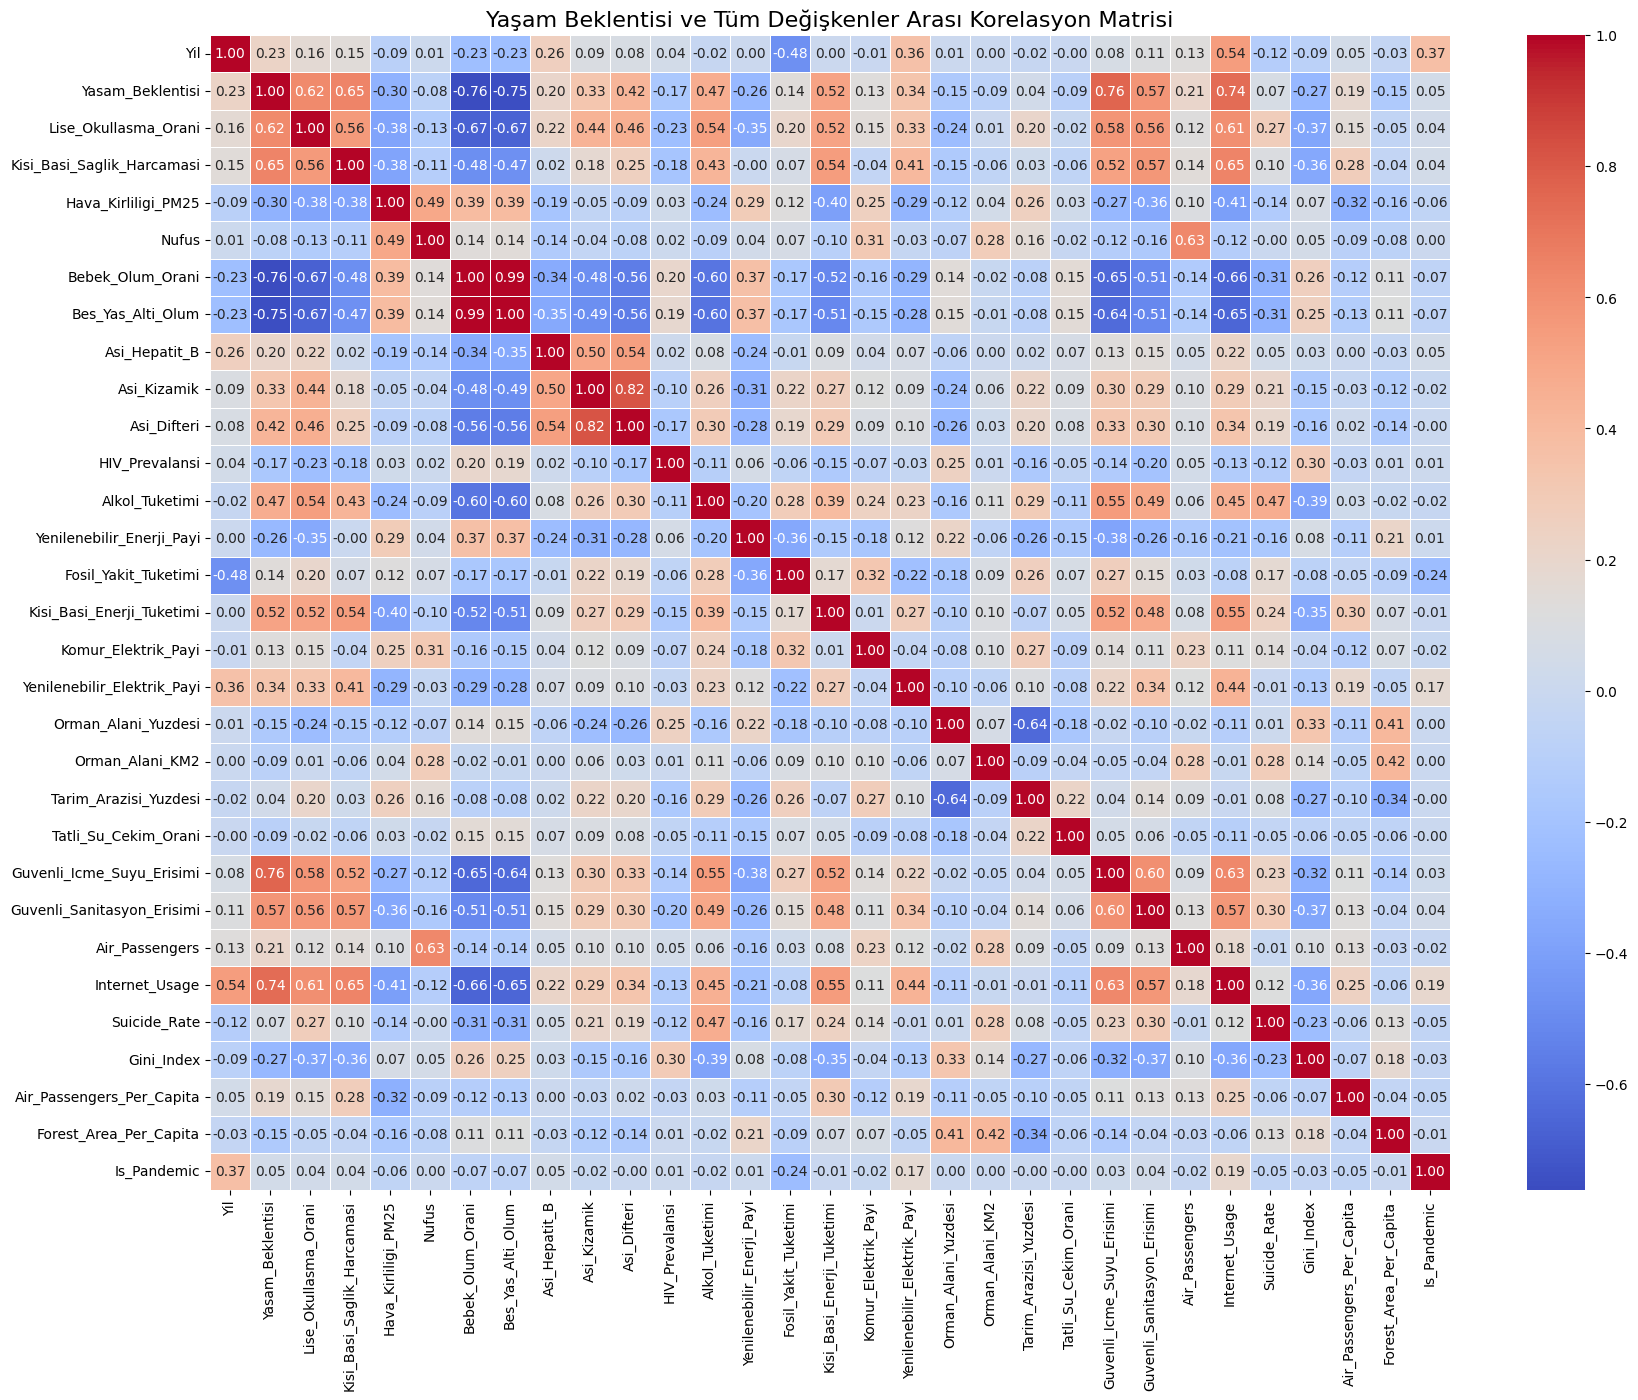

In [15]:
import numpy as np

# Sadece sayısal sütunları seçelim
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns

# Korelasyon matrisini hesapla
corr_matrix = df_combined[numeric_cols].corr()

# Isı haritasını çizdir
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Yaşam Beklentisi ve Tüm Değişkenler Arası Korelasyon Matrisi', fontsize=16)
plt.show()

In [16]:
import numpy as np

# Sadece sayısal sütunları seçelim
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns

# Hedef değişkenle olan korelasyonları yüksekten düşüğe sıralama
correlations = df_combined[numeric_cols].corr()['Yasam_Beklentisi'].sort_values(ascending=False)
print("Yaşam Beklentisi ile En Yüksek Korelasyona Sahip Değişkenler:")
print(correlations)

Yaşam Beklentisi ile En Yüksek Korelasyona Sahip Değişkenler:
Yasam_Beklentisi               1.000000
Guvenli_Icme_Suyu_Erisimi      0.760508
Internet_Usage                 0.736628
Kisi_Basi_Saglik_Harcamasi     0.648433
Lise_Okullasma_Orani           0.621718
Guvenli_Sanitasyon_Erisimi     0.574330
Kisi_Basi_Enerji_Tuketimi      0.517636
Alkol_Tuketimi                 0.469496
Asi_Difteri                    0.423738
Yenilenebilir_Elektrik_Payi    0.337579
Asi_Kizamik                    0.331337
Yil                            0.228328
Air_Passengers                 0.206359
Asi_Hepatit_B                  0.203489
Air_Passengers_Per_Capita      0.185901
Fosil_Yakit_Tuketimi           0.135497
Komur_Elektrik_Payi            0.127944
Suicide_Rate                   0.073103
Is_Pandemic                    0.050191
Tarim_Arazisi_Yuzdesi          0.040353
Nufus                         -0.078657
Orman_Alani_KM2               -0.086005
Tatli_Su_Cekim_Orani          -0.088061
Forest_Area_Per_Ca

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# 1. TERSİNE ÇEVRİLECEK (NEGATİF YÖNLÜ) DEĞİŞKENLERİ DÜZELTME
# Yüksek değerin "kötü" (yani düşük skorlu) olduğu değişkenleri tersine çeviriyoruz.
# Böylece tüm değişkenler yüksek değerin "iyi" olduğu bir forma giriyor.
negatif_yonlu = [
    'Hava_Kirliligi_PM25', 'Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum',
    'Gini_Index', 'Suicide_Rate', 'Alkol_Tuketimi',
    'Fosil_Yakit_Tuketimi', 'Tatli_Su_Cekim_Orani'
]

for col in negatif_yonlu:
    if col in df_combined.columns:
        # Min-Max ile 0-1 arasına çekip 1'den çıkarıyoruz
        col_min = df_combined[col].min()
        col_max = df_combined[col].max()
        if col_max != col_min:
            df_combined[col] = 1 - (df_combined[col] - col_min) / (col_max - col_min)

# 2. ENDEKS GRUPLARINI TANIMLAMA
endeks_gruplari = {
    "Saglik_Bagisiklik": ['Kisi_Basi_Saglik_Harcamasi', 'Asi_Kizamik', 'Asi_Difteri', 'Asi_Hepatit_B'],
    "Sosyo_Teknolojik_Mobilite": ['Lise_Okullasma_Orani', 'Internet_Usage', 'Air_Passengers_Per_Capita'],
    "Cevresel_Kalite": ['Hava_Kirliligi_PM25', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Orman_Alani_Yuzdesi'],
    "Temel_Altyapi_Kaynak": ['Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi', 'Tatli_Su_Cekim_Orani', 'Tarim_Arazisi_Yuzdesi'],
    "Sosyal_Risk_Adalet": ['Gini_Index', 'Suicide_Rate', 'Alkol_Tuketimi']
}

# 3. PCA İLE ENDEKSLERİ OLUŞTURMA
for ad, degiskenler in endeks_gruplari.items():
    # Veriyi seç ve eksik değerleri temizle
    X_group = df_combined[degiskenler].dropna()

    # MinMaxScaler ile 0-1 arasına ölçekle
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_group)

    # PCA uygula (1 bileşen = 1 endeks)
    pca = PCA(n_components=1)
    pc_scores = pca.fit_transform(X_scaled).flatten()

    # İsimleri "EndeksAdı_PCA" olarak tabloya ekle
    sutun_ismi = f"{ad}_PCA"
    df_combined.loc[X_group.index, sutun_ismi] = pc_scores

    # Varyans bilgisini yazdır
    print(f"{sutun_ismi} oluşturuldu. Açıklanan Varyans: %{pca.explained_variance_ratio_[0]*100:.1f}")

print("\nPCA endeksleri başarıyla oluşturuldu.")

Saglik_Bagisiklik_PCA oluşturuldu. Açıklanan Varyans: %48.3
Sosyo_Teknolojik_Mobilite_PCA oluşturuldu. Açıklanan Varyans: %84.2
Cevresel_Kalite_PCA oluşturuldu. Açıklanan Varyans: %43.9
Temel_Altyapi_Kaynak_PCA oluşturuldu. Açıklanan Varyans: %53.6
Sosyal_Risk_Adalet_PCA oluşturuldu. Açıklanan Varyans: %67.6

PCA endeksleri başarıyla oluşturuldu.


In [18]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Endeks gruplarımızı tanımlayalım (Daha önce kullandığımız liste)
endeks_gruplari = {
    "Saglik_Bagisiklik": ['Kisi_Basi_Saglik_Harcamasi', 'Asi_Kizamik', 'Asi_Difteri', 'Asi_Hepatit_B'],
    "Sosyo_Teknolojik_Mobilite": ['Lise_Okullasma_Orani', 'Internet_Usage', 'Air_Passengers_Per_Capita'],
    "Cevresel_Kalite": ['Hava_Kirliligi_PM25', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Orman_Alani_Yuzdesi'],
    "Temel_Altyapi_Kaynak": ['Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi', 'Tatli_Su_Cekim_Orani', 'Tarim_Arazisi_Yuzdesi'],
    "Sosyal_Risk_Adalet": ['Gini_Index', 'Suicide_Rate', 'Alkol_Tuketimi']
}

print("--- PCA ENDEKSİ DEĞİŞKEN AĞIRLIKLARI (KATKILARI) ---\n")

for ad, degiskenler in endeks_gruplari.items():
    # Veriyi hazırla
    X_group = df_combined[degiskenler].dropna()
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_group)

    # PCA'i tekrar çalıştır
    pca = PCA(n_components=1)
    pca.fit(X_scaled)

    # Ağırlıkları çıkar (Loadings)
    # Mutlak değer alıyoruz çünkü ağırlığın yönünden ziyade büyüklüğü (etkisi) önemli
    weights = np.abs(pca.components_[0])

    # Ağırlıkları normalize et (toplamı 1 yap, yani %100'e tamamla)
    normalized_weights = weights / np.sum(weights)

    # DataFrame ile güzelce göster
    df_weights = pd.DataFrame({
        'Değişken': degiskenler,
        'Endeks_Katkı_Payı': np.round(normalized_weights, 3)
    }).sort_values(by='Endeks_Katkı_Payı', ascending=False)

    print(f"--- {ad.upper()} ---")
    print(df_weights.to_string(index=False))
    print("\n")

--- PCA ENDEKSİ DEĞİŞKEN AĞIRLIKLARI (KATKILARI) ---

--- SAGLIK_BAGISIKLIK ---
                  Değişken  Endeks_Katkı_Payı
             Asi_Hepatit_B              0.304
Kisi_Basi_Saglik_Harcamasi              0.280
               Asi_Difteri              0.225
               Asi_Kizamik              0.191


--- SOSYO_TEKNOLOJIK_MOBILITE ---
                 Değişken  Endeks_Katkı_Payı
           Internet_Usage              0.702
     Lise_Okullasma_Orani              0.250
Air_Passengers_Per_Capita              0.048


--- CEVRESEL_KALITE ---
                 Değişken  Endeks_Katkı_Payı
      Orman_Alani_Yuzdesi              0.370
Yenilenebilir_Enerji_Payi              0.343
     Fosil_Yakit_Tuketimi              0.277
      Hava_Kirliligi_PM25              0.010


--- TEMEL_ALTYAPI_KAYNAK ---
                  Değişken  Endeks_Katkı_Payı
 Guvenli_Icme_Suyu_Erisimi              0.455
Guvenli_Sanitasyon_Erisimi              0.424
     Tarim_Arazisi_Yuzdesi              0.104
      Ta

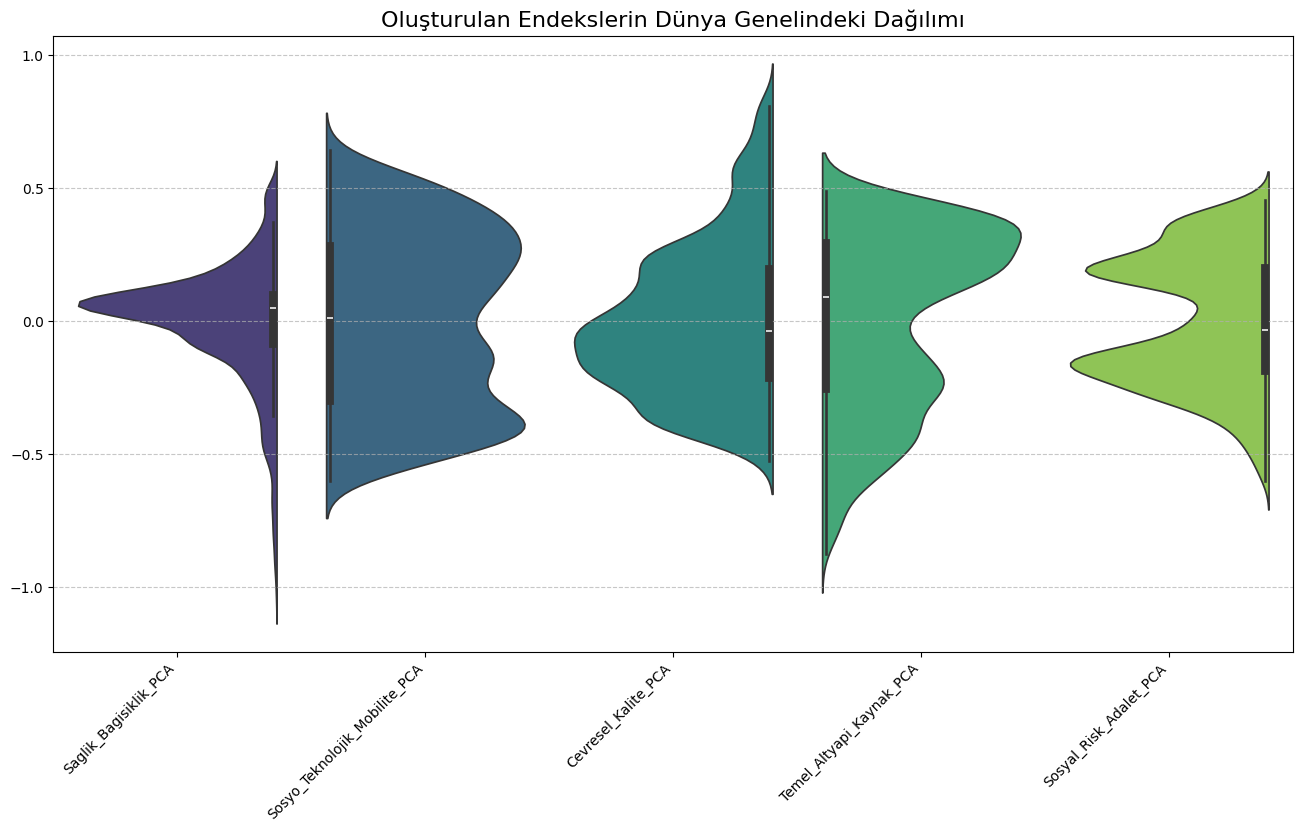

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Oluşturduğumuz 5 endeksin isimleri
endeks_listesi = [
    'Saglik_Bagisiklik_PCA',
    'Sosyo_Teknolojik_Mobilite_PCA',
    'Cevresel_Kalite_PCA',
    'Temel_Altyapi_Kaynak_PCA',
    'Sosyal_Risk_Adalet_PCA'
]

plt.figure(figsize=(16, 8))
sns.violinplot(data=df_combined[endeks_listesi], palette="viridis", split=True)
plt.title('Oluşturulan Endekslerin Dünya Genelindeki Dağılımı', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

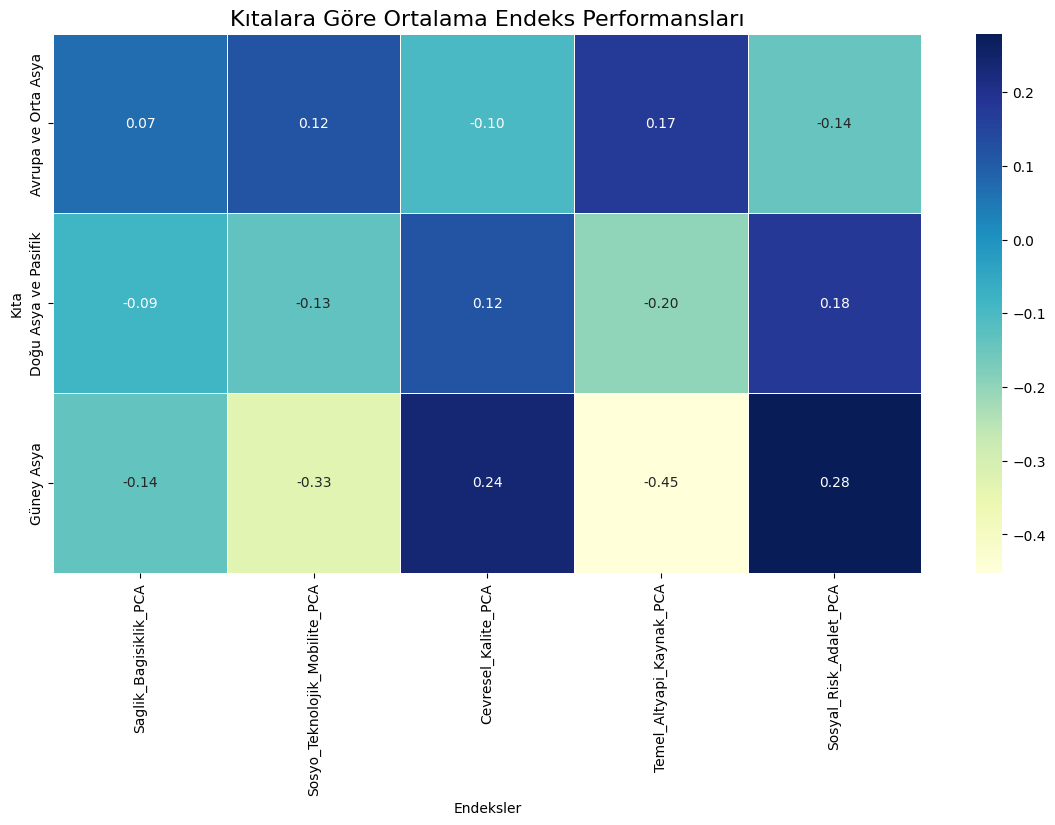

In [20]:
# Kıta bazında endeks ortalamaları
kita_analizi = df_combined.groupby('Kita')[endeks_listesi].mean()

plt.figure(figsize=(14, 7))
sns.heatmap(kita_analizi, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title('Kıtalara Göre Ortalama Endeks Performansları', fontsize=16)
plt.ylabel('Kıta')
plt.xlabel('Endeksler')
plt.show()

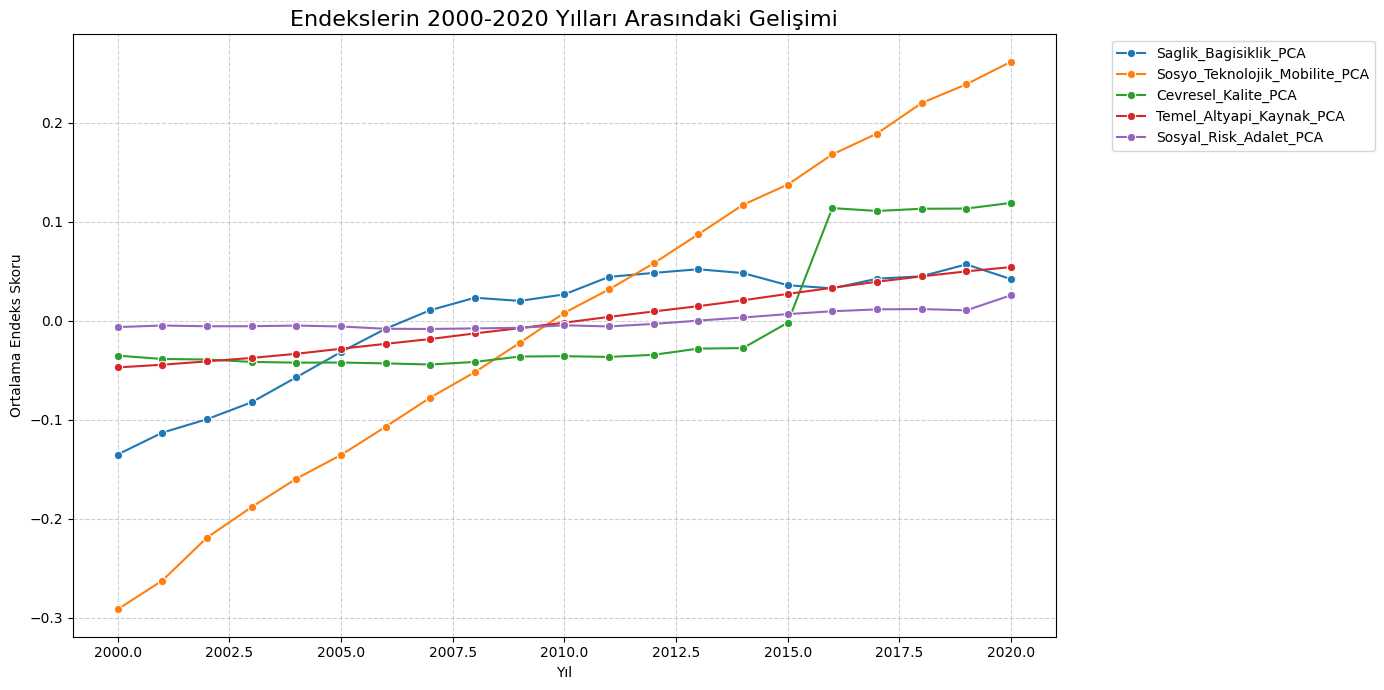

In [21]:
# 3. Zaman İçindeki Gelişim Trendi
plt.figure(figsize=(14, 7))

# Veriyi yıllara göre gruplayıp ortalamalarını alalım
df_trend = df_combined.groupby('Yil')[endeks_listesi].mean().reset_index()

# Her endeks için bir çizgi (line) çizdirelim
for endeks in endeks_listesi:
    sns.lineplot(data=df_trend, x='Yil', y=endeks, label=endeks, marker='o')

plt.title('Endekslerin 2000-2020 Yılları Arasındaki Gelişimi', fontsize=16)
plt.ylabel('Ortalama Endeks Skoru')
plt.xlabel('Yıl')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

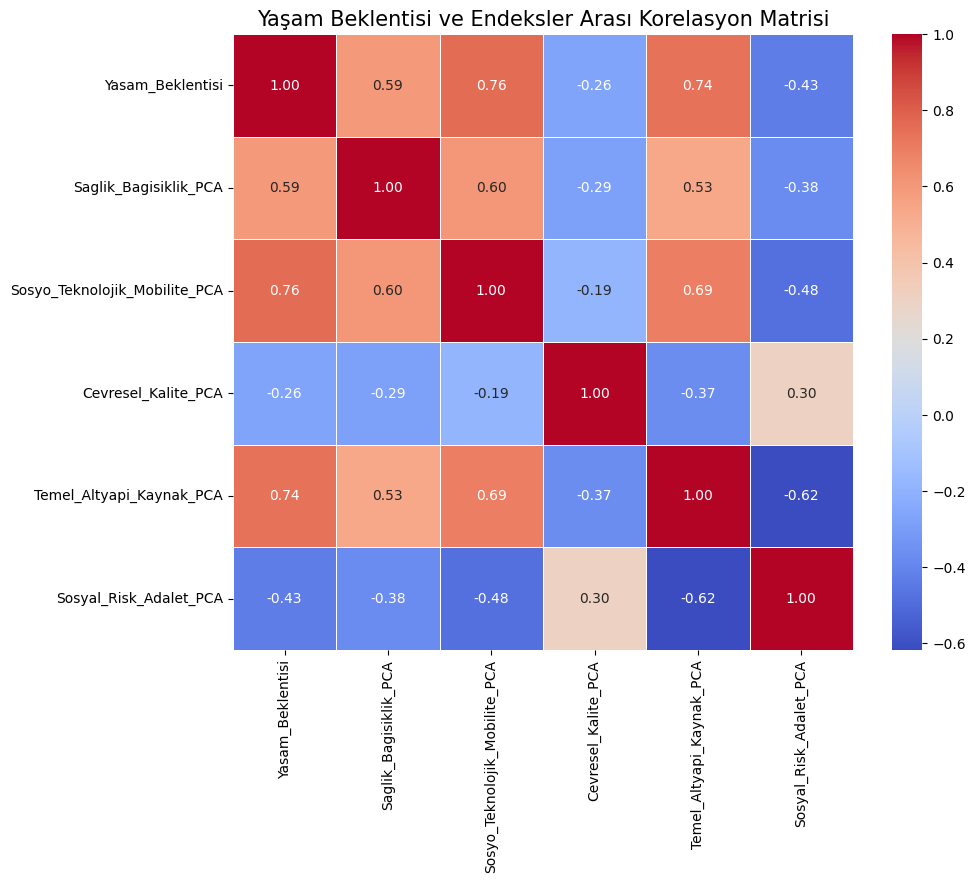

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Korelasyon için hedef değişken ve endekslerimizi seçelim
cols_to_correlate = ['Yasam_Beklentisi'] + endeks_listesi

# 2. Korelasyon matrisini hesaplayalım
corr_matrix = df_combined[cols_to_correlate].corr()

# 3. Görselleştirme (Isı Haritası)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Yaşam Beklentisi ve Endeksler Arası Korelasyon Matrisi', fontsize=15)
plt.show()

In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Özellikler (X) ve Hedef (y) Belirleme
# İsimleri güncellenmiş PCA endeksleri ile eşleştirdik
features = [
    'Sosyo_Teknolojik_Mobilite_PCA',
    'Saglik_Bagisiklik_PCA',
    'Cevresel_Kalite_PCA',
    'Temel_Altyapi_Kaynak_PCA',
    'Sosyal_Risk_Adalet_PCA',
    'Is_Pandemic'
]

# Eksik verileri (varsa) temizleyelim ve X, y tanımlayalım
df_model = df_combined.dropna(subset=features + ['Yasam_Beklentisi'])
X = df_model[features]
y = df_model['Yasam_Beklentisi']

# 2. Veriyi Eğitim ve Test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    "SVR": SVR(kernel='rbf')
}

# 3. Eğitim ve Değerlendirme Döngüsü
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)

    results.append({"Model": name, "R2 Score": r2, "RMSE": rmse})

# 4. Sonuçları Tablo Haline Getirme
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("Model Performans Karşılaştırması:")
print(df_results.to_string(index=False))

Model Performans Karşılaştırması:
            Model  R2 Score     RMSE
          XGBoost  0.961977 1.212822
    Random Forest  0.951167 1.374455
Gradient Boosting  0.863086 2.301441
              SVR  0.759522 3.050093
 Ridge Regression  0.668722 3.579909
Linear Regression  0.668412 3.581587
 Lasso Regression  0.382002 4.889553


In [24]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 1. K-Fold yapısını belirleyelim (Veriyi 5 parçaya böler)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Sonuçları tutmak için yeni bir liste
cv_results = []

print(f"{'Model':<20} | {'Ortalama R2':<12} | {'Std Sapma':<10}")
print("-" * 50)

# 3. Her model için Cross-Validation döngüsü
for name, model in models.items():
    # cv=kf ile veriyi 5 farklı parçada test ediyoruz
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    cv_results.append({
        "Model": name,
        "Mean R2": scores.mean(),
        "Std": scores.std()
    })

    print(f"{name:<20} | {scores.mean():.4f}       | {scores.std():.4f}")

# 4. Detaylı tablo
df_cv_results = pd.DataFrame(cv_results).sort_values(by="Mean R2", ascending=False)

Model                | Ortalama R2  | Std Sapma 
--------------------------------------------------
Linear Regression    | 0.6835       | 0.0157
Ridge Regression     | 0.6835       | 0.0156
Lasso Regression     | 0.3863       | 0.0100
Random Forest        | 0.9502       | 0.0039
Gradient Boosting    | 0.8711       | 0.0119
XGBoost              | 0.9578       | 0.0029
SVR                  | 0.7671       | 0.0140


In [25]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb # Added this import statement

# 1. Varsayılan (Default) Model
default_model = xgb.XGBRegressor() # Changed from XGBoostRegressor()
default_model.fit(X_train, y_train)
default_r2 = default_model.score(X_test, y_test)

# 2. İyileştirilmiş (Tuned) Model - Parametreleri biz belirliyoruz
# "max_depth" (derinlik), "n_estimators" (ağaç sayısı) ve "learning_rate" (öğrenme hızı)
params = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(xgb.XGBRegressor(), params, cv=5, scoring='r2') # Changed from XGBoostRegressor()
grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
tuned_r2 = tuned_model.score(X_test, y_test)

# 3. Sonuçları Karşılaştır
print(f"--- Model İyileştirme (Tuning) Sonuçları ---")
print(f"Varsayılan Model R² Skoru: {default_r2:.4f}")
print(f"İyileştirilmiş Model R² Skoru: {tuned_r2:.4f}")
print(f"En İyi Parametreler: {grid_search.best_params_}")

--- Model İyileştirme (Tuning) Sonuçları ---
Varsayılan Model R² Skoru: 0.9567
İyileştirilmiş Model R² Skoru: 0.9602
En İyi Parametreler: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


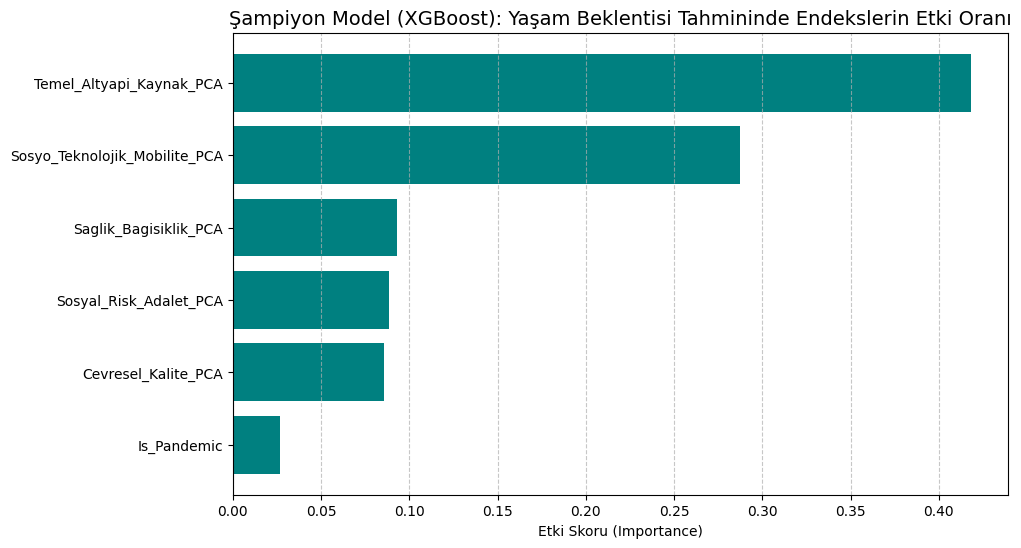

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Şampiyon modelimizden önem skorlarını alalım
# Not: XGBoost'ta feature_importances_ özelliği standarttır
importances = models["XGBoost"].feature_importances_
feature_names = features

# 2. Veriyi kolay sıralamak için bir DataFrame'e koyalım
df_importance = pd.DataFrame({'Endeks': feature_names, 'Onem': importances})
df_importance = df_importance.sort_values(by='Onem', ascending=True)

# 3. Görselleştirme
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Endeks'], df_importance['Onem'], color='teal')
plt.xlabel('Etki Skoru (Importance)')
plt.title('Şampiyon Model (XGBoost): Yaşam Beklentisi Tahmininde Endekslerin Etki Oranı', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

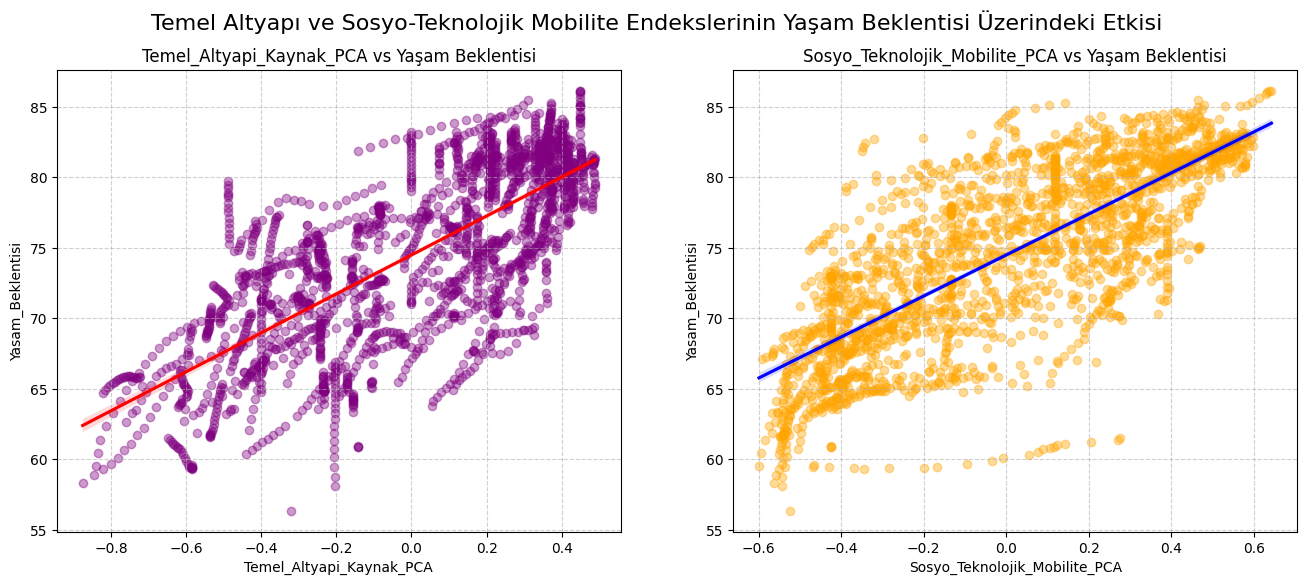

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# İki ana endeksimizi belirleyelim
endeks_1 = 'Temel_Altyapi_Kaynak_PCA'
endeks_2 = 'Sosyo_Teknolojik_Mobilite_PCA'

# Scatter plot oluşturma
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Temel Altyapı ve Kaynak Endeksi vs Yaşam Beklentisi
sns.regplot(x=endeks_1, y='Yasam_Beklentisi', data=df_combined,
            ax=axes[0], scatter_kws={'alpha':0.4, 'color': 'purple'}, line_kws={'color':'red'})
axes[0].set_title(f'{endeks_1} vs Yaşam Beklentisi')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Sosyo-Teknolojik ve Mobilite Endeksi vs Yaşam Beklentisi
sns.regplot(x=endeks_2, y='Yasam_Beklentisi', data=df_combined,
            ax=axes[1], scatter_kws={'alpha':0.4, 'color': 'orange'}, line_kws={'color':'blue'})
axes[1].set_title(f'{endeks_2} vs Yaşam Beklentisi')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Temel Altyapı ve Sosyo-Teknolojik Mobilite Endekslerinin Yaşam Beklentisi Üzerindeki Etkisi', fontsize=16)
plt.show()

Çıkarılan Özellik              | Yeni R2 Skoru   | Düşüş (Etki Payı)
-----------------------------------------------------------------
Sosyo_Teknolojik_Mobilite_PCA  | 0.3769          | 0.5809
Saglik_Bagisiklik_PCA          | 0.4425          | 0.5153
Cevresel_Kalite_PCA            | 0.4352          | 0.5226
Temel_Altyapi_Kaynak_PCA       | 0.3847          | 0.5731
Sosyal_Risk_Adalet_PCA         | 0.4619          | 0.4959
Is_Pandemic                    | 0.4803          | 0.4775


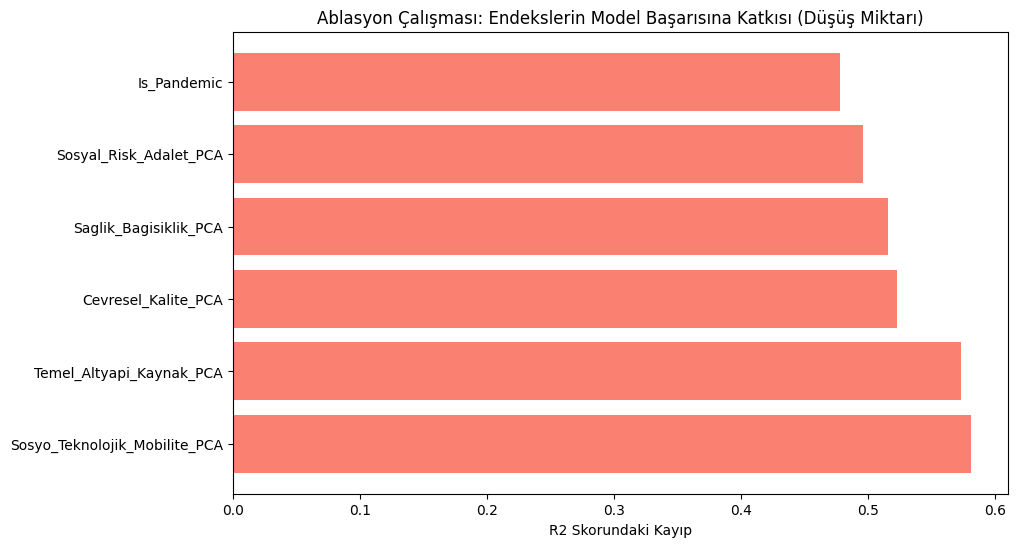

In [28]:
# 1. Mevcut özellik listemiz
features = [
    'Sosyo_Teknolojik_Mobilite_PCA',
    'Saglik_Bagisiklik_PCA',
    'Cevresel_Kalite_PCA',
    'Temel_Altyapi_Kaynak_PCA',
    'Sosyal_Risk_Adalet_PCA',
    'Is_Pandemic'
]

# 2. Ablasyon Döngüsü
ablation_results = []
baseline_score = 0.9578 # XGBoost'un tam model skoru

print(f"{'Çıkarılan Özellik':<30} | {'Yeni R2 Skoru':<15} | {'Düşüş (Etki Payı)':<15}")
print("-" * 65)

for feature in features:
    # O özelliği çıkarıp yeni bir özellik listesi oluştur
    temp_features = [f for f in features if f != feature]

    # Veriyi hazırla
    X_ablated = df_combined[temp_features]
    y = df_combined['Yasam_Beklentisi']

    # Modeli tekrar eğit (XGBoost şampiyon modelimiz)
    model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
    scores = cross_val_score(model, X_ablated, y, cv=5, scoring='r2')
    mean_score = scores.mean()

    # Etki payını hesapla
    drop = baseline_score - mean_score
    ablation_results.append({"Feature": feature, "Score": mean_score, "Drop": drop})

    print(f"{feature:<30} | {mean_score:.4f}          | {drop:.4f}")

# 3. Görselleştirme
df_ablation = pd.DataFrame(ablation_results).sort_values(by="Drop", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_ablation['Feature'], df_ablation['Drop'], color='salmon')
plt.title('Ablasyon Çalışması: Endekslerin Model Başarısına Katkısı (Düşüş Miktarı)')
plt.xlabel('R2 Skorundaki Kayıp')
plt.show()

In [29]:
# Tüm endekslerin birbirleriyle korelasyonuna bak
print(df_combined[features].corr())

                               Sosyo_Teknolojik_Mobilite_PCA  \
Sosyo_Teknolojik_Mobilite_PCA                       1.000000   
Saglik_Bagisiklik_PCA                               0.602616   
Cevresel_Kalite_PCA                                -0.186323   
Temel_Altyapi_Kaynak_PCA                            0.690666   
Sosyal_Risk_Adalet_PCA                             -0.482909   
Is_Pandemic                                         0.179539   

                               Saglik_Bagisiklik_PCA  Cevresel_Kalite_PCA  \
Sosyo_Teknolojik_Mobilite_PCA               0.602616            -0.186323   
Saglik_Bagisiklik_PCA                       1.000000            -0.286105   
Cevresel_Kalite_PCA                        -0.286105             1.000000   
Temel_Altyapi_Kaynak_PCA                    0.533783            -0.367149   
Sosyal_Risk_Adalet_PCA                     -0.375413             0.298969   
Is_Pandemic                                 0.042802             0.092582   

           

In [30]:
def yasam_beklentisi_simulasyonu(ulke_adi, yil):
    # Veri setindeki tam ismi kullanıyoruz
    country_data = df_combined[(df_combined['Ulke_Adi'] == ulke_adi) & (df_combined['Yil'] == yil)]

    if country_data.empty:
        print(f"Hata: '{ulke_adi}' için {yil} yılı verisi bulunamadı. Lütfen ülke ismini ve yıl aralığını kontrol edin.")
        return

    features = [
        'Sosyo_Teknolojik_Mobilite_PCA',
        'Saglik_Bagisiklik_PCA',
        'Cevresel_Kalite_PCA',
        'Temel_Altyapi_Kaynak_PCA',
        'Sosyal_Risk_Adalet_PCA',
        'Is_Pandemic'
    ]

    current_values = country_data[features].values
    current_prediction = models["XGBoost"].predict(current_values)[0]

    print(f"--- {ulke_adi} ({yil}) Simülasyonu ---")
    print(f"Mevcut Tahmini Yaşam Beklentisi: {current_prediction:.2f} Yıl")
    print("-" * 40)

    # Senaryo: Altyapı ve Sağlık endekslerinde %10 iyileşme
    idx_altyapi = features.index('Temel_Altyapi_Kaynak_PCA')
    idx_saglik = features.index('Saglik_Bagisiklik_PCA')

    improved_values = current_values.copy()
    improved_values[0, idx_altyapi] = np.clip(improved_values[0, idx_altyapi] * 1.10, -1, 1)
    improved_values[0, idx_saglik] = np.clip(improved_values[0, idx_saglik] * 1.10, -1, 1)

    new_prediction = models["XGBoost"].predict(improved_values)[0]
    fark = new_prediction - current_prediction

    print(f"Senaryo: Temel Altyapı ve Sağlık endekslerinde %10 iyileşme.")
    print(f"Yeni Tahmini Yaşam Beklentisi: {new_prediction:.2f} Yıl")
    print(f"Tahmini Kazanç: +{fark:.2f} Yıl")

# Kullanım:
yasam_beklentisi_simulasyonu('Turkiye', 2019)

--- Turkiye (2019) Simülasyonu ---
Mevcut Tahmini Yaşam Beklentisi: 77.64 Yıl
----------------------------------------
Senaryo: Temel Altyapı ve Sağlık endekslerinde %10 iyileşme.
Yeni Tahmini Yaşam Beklentisi: 77.74 Yıl
Tahmini Kazanç: +0.09 Yıl


In [31]:
import joblib

# Şampiyon modelimizi kaydedelim
joblib.dump(models["XGBoost"], 'yasam_beklentisi_model.pkl')
print("Model başarıyla 'yasam_beklentisi_model.pkl' olarak kaydedildi.")

Model başarıyla 'yasam_beklentisi_model.pkl' olarak kaydedildi.


In [32]:
!pip install gradio

In [33]:
import gradio as gr
import joblib
import pandas as pd

# 1. Kaydettiğin modeli yükle
model = joblib.load('yasam_beklentisi_model.pkl')

def yasam_beklentisi_tahmin(sosyo_tekno, saglik, cevresel, altyapi, sosial_risk, is_pandemic):
    input_data = pd.DataFrame({
        'Sosyo_Teknolojik_Mobilite_PCA': [sosyo_tekno],
        'Saglik_Bagisiklik_PCA': [saglik],
        'Cevresel_Kalite_PCA': [cevresel],
        'Temel_Altyapi_Kaynak_PCA': [altyapi],
        'Sosyal_Risk_Adalet_PCA': [sosial_risk],
        'Is_Pandemic': [is_pandemic]
    })
    tahmin = model.predict(input_data)[0]
    return f"{tahmin:.2f} Yıl"

# 3. Gradio Görsel Arayüzünü Oluştur
arayuz = gr.Interface(
    fn=yasam_beklentisi_tahmin,
    inputs=[
        # gr.Slider hem görseldir hem de aralığı net gösterir
        gr.Slider(minimum=-5, maximum=5, step=0.1, label="Sosyo-Teknolojik Mobilite PCA", info="Önerilen aralık: -3.0 ile 3.0"),
        gr.Slider(minimum=-5, maximum=5, step=0.1, label="Sağlık ve Bağışıklık PCA", info="Önerilen aralık: -3.0 ile 3.0"),
        gr.Slider(minimum=-5, maximum=5, step=0.1, label="Çevresel Kalite PCA", info="Önerilen aralık: -3.0 ile 3.0"),
        gr.Slider(minimum=-5, maximum=5, step=0.1, label="Temel Altyapı ve Kaynak PCA", info="Önerilen aralık: -3.0 ile 3.0"),
        gr.Slider(minimum=-5, maximum=5, step=0.1, label="Sosyal Risk ve Adalet PCA", info="Önerilen aralık: -3.0 ile 3.0"),
        gr.Radio(choices=[0, 1], label="Pandemi Yılı mı?", info="0: Hayır, 1: Evet")
    ],
    outputs=gr.Text(label="Tahmini Yaşam Beklentisi Sonucu"),
    title="🌍 Yaşam Beklentisi Simülasyonu",
    description="Lütfen PCA endeks değerlerini kaydırarak modelin tahminini gözlemleyin."
)

arayuz.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a5ee08ff1488d8da44.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
